In [3]:
import cv2
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import re


In [4]:
#os.chdir(r"/home/lcoussy/Yolo_project")
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project")
from classes.CNN_pytorch_pretrained import CNN_model, YoloDataset, YoloLoss, YOLOv1, YOLO_visual, YOLOVisualizer #import my class CNN

def should_add(filename):
    match = re.match(r"(\d{4})_(\d{6})", filename)
    if not match:
        return False  # name doesn't match pattern
    
    year = int(match.group(1))
    index = int(match.group(2))

    # Stop if year > 2011
    if year > 2011:
        return False
    
    # Stop if same year but index > 2500
    if year == 2011 and index > 2500:
        return False
    
    return True

In [5]:
### old version
#os.chdir(r"/home/lcoussy/Yolo_project/data/Pascal_VOC/train")
#os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC")
#path_list = [r"/home/lcoussy/Yolo_project/data/Pascal_VOC/train",r"/home/lcoussy/Yolo_project/data/Pascal_VOC/valid"]
#path_list = [r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC\train",r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC\valid"]

### new version

#os.chdir(r"/home/lcoussy/Yolo_project/dataset")
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset")
#path_list = [r"/home/lcoussy/Yolo_project/dataset/train",r"/home/lcoussy/Yolo_project/dataset/valid"]
path_list = [r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset\train",r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset\valid"]

xml_list = []
for path in path_list:
    for filename in os.listdir(path):
        if not filename.endswith('.xml'): continue
        #if should_add(filename):
        fullname = os.path.join(path, filename)
        xml_list.append(fullname)

my_CNN = CNN_model()
my_CNN.get_annotation(xml_list)
my_CNN.encode_pictures()

In [6]:
#os.chdir(r"/home/lcoussy/Yolo_project")
os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project")

my_CNN.df.to_json(r"data/annot_df.json",orient="records")
torch.save(my_CNN.encoded_picture_annot, r"data/encoded_picture.pt")

In [7]:
my_classes = ['aeroplane','person','boat','bird','tvmonitor','sheep','diningtable','bottle','horse','train','motorbike','sofa','chair','cow',
                'bicycle','car','cat','bus','pottedplant','dog']

In [8]:
df_encoded = torch.load(r"data/encoded_picture.pt",weights_only=False)
df_encoded

,file_name,encoded_grid
1,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
2,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
3,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
4,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
5,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
...,...,...
32222,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32223,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32224,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32225,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."


In [9]:
def split_Voc(X,y,test_size=0.2,random_state=42):
    if test_size == 0:
        X_test = pd.DataFrame()
        y_test = pd.DataFrame()
        return X, X_test, y, y_test
    else:
        return train_test_split(X,y,test_size=test_size, random_state=random_state)

In [10]:
#X_train, X_test, y_train, y_test = train_test_split(df_encoded['file_name'],df_encoded['encoded_grid'],test_size=0.4, random_state=42)

X_train, X_test, y_train, y_test = split_Voc(df_encoded['file_name'],df_encoded['encoded_grid'],test_size=0)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [11]:
train_dataset = YoloDataset(X_train, y_train)
test_dataset = YoloDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [12]:
def show_yolo_label(img_tensor, label_tensor, img_size=448, conf_threshold=0.5, S=7):
    # Convert tensor to numpy and back to OpenCV format (HWC)
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    # Draw YOLO grid
    step = img_size // S
    for i in range(1, S):
        # horizontal line
        cv2.line(img, (0, i*step), (img_size, i*step), color=(255, 255, 255), thickness=1)
        # vertical line
        cv2.line(img, (i*step, 0), (i*step, img_size), color=(255, 255, 255), thickness=1)

    # Draw bounding boxes
    if label_tensor.ndim == 3:
        for i in range(S):
            for j in range(S):
                cell = label_tensor[i, j]
                if cell[0] > conf_threshold:  # confidence score
                    x, y, w, h = cell[1:5]
                    # Convert to absolute coords
                    x_center = (j + x) / S * img_size
                    y_center = (i + y) / S * img_size
                    w_pixel = w * img_size
                    h_pixel = h * img_size
                    x1 = int(x_center - w_pixel / 2)
                    y1 = int(y_center - h_pixel / 2)
                    x2 = int(x_center + w_pixel / 2)
                    y2 = int(y_center + h_pixel / 2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    else:
        boxes = label_tensor.view(-1, 5 if label_tensor.shape[-1] == 5 else 4)
        for box in boxes:
            if box.numel() == 5:
                _, x, y, w, h = box
            else:
                x, y, w, h = box
            x1 = int((x - w/2) * img_size)
            y1 = int((y - h/2) * img_size)
            x2 = int((x + w/2) * img_size)
            y2 = int((y + h/2) * img_size)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


c:\Users\Lucas\Desktop\vacantion classes\Yolo project\classes\CNN_pytorch_pretrained.py:656: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.Y_tensor[idx], dtype=torch.float32)


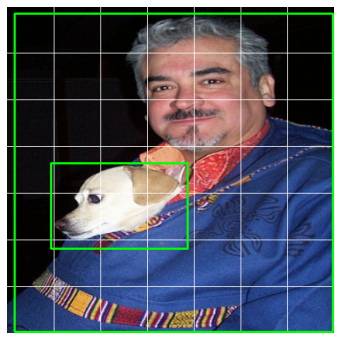

In [13]:
img, label = train_dataset[0]
show_yolo_label(img, label)

In [14]:
def compare_pred_vs_true( img_tensor, pred_tensor, target_tensor, img_size=448, conf_threshold=0.3):
    """
    Visualize both predicted and ground truth boxes on the same image.
    Predicted boxes: green
    Ground truth boxes: red
    """

    # Convert tensor to numpy image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    S = 7
    step = img_size // S

    for i in range(S):
        for j in range(S):
            # === Ground truth ===
            tcell = target_tensor[i, j]
            if tcell[0] > 0:  # object present
                tx, ty, tw, th = tcell[1:5]
                x_center = (j + tx) / S * img_size
                y_center = (i + ty) / S * img_size
                w_pixel = tw * img_size
                h_pixel = th * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # RED = ground truth

            # === Prediction ===
            pcell = pred_tensor[i, j]
            for b in range(2):
                conf = torch.sigmoid(torch.tensor(pcell[0])).item()
                if conf < conf_threshold:
                    continue
                x, y, w, h = pcell[b*5+1:b*5+5]
                x_center = (j + x) / S * img_size
                y_center = (i + y) / S * img_size
                w_pixel = abs(w) * img_size
                h_pixel = abs(h) * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                x1 = max(0, min(x1, img.shape[1] - 1))
                x2 = max(0, min(x2, img.shape[1] - 1))
                y1 = max(0, min(y1, img.shape[0] - 1))
                y2 = max(0, min(y2, img.shape[0] - 1))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # GREEN = prediction

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("YOLO — Predicted (green) vs Ground Truth (red)")
    plt.axis('off')
    plt.show()

## Training

# -------------------------------
# 1️⃣ Hyperparameters (MATCH YOLOv1 PAPER)
# -------------------------------
S, B, C = 7, 2, 20
batch_size = 1

num_epochs = 20            # total = 10 warmup + 75 + 30 + 30
warmup_epochs = 15

lr_warmup_start = 1e-3
lr_warmup_end   = 1e-2      # Peak LR after warmup (YOLOv1 main LR)

lr_stage1 = 5e-3             # Epochs 10 → 85
lr_stage2 = 1e-4             # Epochs 85 → 115
lr_stage3 = 5e-5             # Epochs 115 → 145

max_grad_norm = 5

device = "cuda"
my_model = YOLOv1(S=S,B=B,C=C,pretrained=True)
my_model = my_model.to(device)

for name, p in my_model.named_parameters():
    if "features" in name:
        p.requires_grad = True
    else:
        p.requires_grad = True

criterion = YoloLoss(S=S, B=B, C=C, l_obj=5, l_nobj=0.1)

#optimizer = optim.SGD(my_model.parameters(), lr=lr_warmup_start, momentum=0.7, weight_decay=5e-4)
optimizer = optim.Adam(my_model.parameters(), lr=0.0001)
# -------------------------------
# 3️⃣ Warmup Setup
# -------------------------------
total_iters_per_epoch = len(train_loader)
total_warmup_iters = warmup_epochs * total_iters_per_epoch
global_step = 0

train_losses = []

# -------------------------------
# 4️⃣ Training Loop
# -------------------------------
print(f"\n🚀 Starting Training for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    my_model.train()
    running_loss = 0.0
    display_count = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = my_model(imgs)
        #print(preds.shape)
        if epoch % 9 == 0 and display_count < 3: 
            compare_pred_vs_true(imgs[0].cpu(), preds[0], target_tensor=labels[0])
            display_count += 1
        loss = criterion.yolo_loss_vectorized(preds, labels)
        loss.backward()

        # Clip exploding gradients
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        # -------------------------
        # Learning Rate Schedule
        # -------------------------
        if global_step < total_warmup_iters:
            # Linear warmup
            lr = lr_warmup_start + (lr_warmup_end - lr_warmup_start) * (global_step / total_warmup_iters)
        else:
            # Stage decay after warmup
            if epoch < warmup_epochs + 50:
                lr = lr_stage1
            elif epoch < warmup_epochs + 50 + 30:
                lr = lr_stage2
            else:
                lr = lr_stage3

        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        optimizer.step()
        global_step += 1
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    if epoch % 20 == 0: 
        print(f"✅ Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | LR: {lr:.6f}")

# -------------------------------
# 5️⃣ Save Model
# -------------------------------
torch.save(my_model.state_dict(), "yolov1_trained.pth")
print("\n💾 Model saved as yolov1_trained.pth\n")

# -------------------------------
# 6️⃣ Plot Training Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, linewidth=2)
plt.title("YOLOv1 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Epoch 1/130:   0%|          | 0/1008 [00:00<?, ?it/s]


🚀 Starting Training for 130 epochs...



C:\Users\Lucas\AppData\Local\Temp\ipykernel_14140\3285736511.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


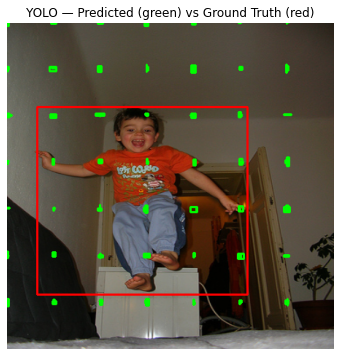

xy_loss tensor(52.7636, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(50.4454, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(67.3042, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(70.2041, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(0.2026, device='cuda:0', grad_fn=<SumBackward0>)


Epoch 1/130:   0%|          | 1/1008 [00:13<3:43:16, 13.30s/it]

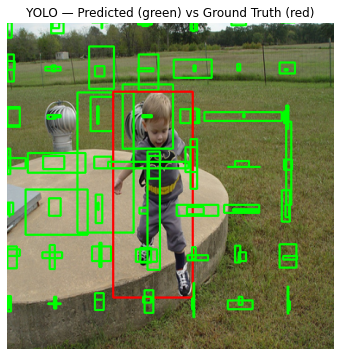

xy_loss tensor(39.1359, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(27.9189, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(62.0780, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(66.3806, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(2.7163, device='cuda:0', grad_fn=<SumBackward0>)


Epoch 1/130:   0%|          | 2/1008 [00:25<3:39:54, 13.12s/it]

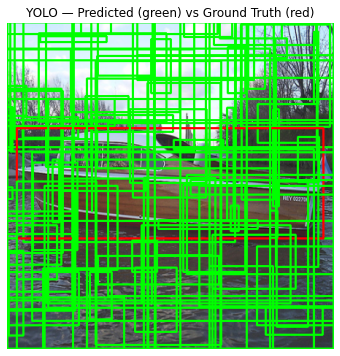

xy_loss tensor(31.7876, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(27.6305, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(44.3932, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(164.9949, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(179.7525, device='cuda:0', grad_fn=<SumBackward0>)


Epoch 1/130:   0%|          | 3/1008 [00:38<3:37:09, 12.97s/it]

xy_loss tensor(33.7842, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(16.9736, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(66.8216, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(91.1524, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(17.0388, device='cuda:0', grad_fn=<SumBackward0>)


Epoch 1/130:   0%|          | 4/1008 [00:49<3:29:04, 12.49s/it]

xy_loss tensor(28.6150, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(19.3718, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(57.5785, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(67.9322, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(7.0992, device='cuda:0', grad_fn=<SumBackward0>)


...

Epoch 1/130:   2%|▏         | 22/1008 [04:10<3:07:14, 11.39s/it]

xy_loss tensor(12.1959, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(7.4059, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(21.0190, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(61.2494, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(125.5462, device='cuda:0', grad_fn=<SumBackward0>)


Epoch 1/130:   2%|▏         | 23/1008 [04:22<3:10:02, 11.58s/it]

xy_loss tensor(11.1339, device='cuda:0', grad_fn=<SumBackward0>)
wh_loss tensor(5.8856, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_obj tensor(25.6403, device='cuda:0', grad_fn=<SumBackward0>)
class_loss tensor(58.1192, device='cuda:0', grad_fn=<SumBackward0>)
conf_loss_noobj tensor(92.9040, device='cuda:0', grad_fn=<SumBackward0>)


KeyboardInterrupt: 

In [15]:
# -------------------------------
# 1️⃣ Hyperparameters
# -------------------------------
S, B, C = 7, 2, 20
batch_size = 32

num_epochs = 130
device = "cuda"

my_model = YOLOv1(S=S, B=B, C=C, pretrained=True).to(device)

for name, p in my_model.named_parameters():
    p.requires_grad = True

criterion = YoloLoss(S=S, B=B, C=C, l_obj=5, l_nobj=0.1)

# ❗ FIXED learning rate (no warmup, no decay)
optimizer = optim.Adam(my_model.parameters(), lr=1e-4)

train_losses = []

print(f"\n🚀 Starting Training for {num_epochs} epochs...\n")

# -------------------------------
# 2️⃣ Training Loop
# -------------------------------
for epoch in range(num_epochs):
    my_model.train()
    running_loss = 0.0
    display_count = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):

        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = my_model(imgs)

        # Optional visualization
        if epoch % 9 == 0 and display_count < 3:
            compare_pred_vs_true(imgs[0].cpu(), preds[0], target_tensor=labels[0])
            display_count += 1

        loss = criterion.yolo_loss_vectorized(preds, labels)
        loss.backward()

        # (optional) gradient clipping
        # torch.nn.utils.clip_grad_norm_(my_model.parameters(), 5)

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"💡 Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | LR: 0.0001")

# -------------------------------
# 3️⃣ Save Model
# -------------------------------
torch.save(my_model.state_dict(), "slurm/output/yolov1_trained3.pth")
print("\n💾 Model saved as yolov1_trained3.pth\n")

# -------------------------------
# 4️⃣ Plot Training Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, linewidth=2)
plt.title("YOLOv1 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
S, B, C = 7, 2, 20

model = YOLOv1(S=S, B=B, C=C).to(device)
criterion = YoloLoss(S=S, B=B, C=C)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

loaded_model = YOLOv1(S=S, B=B, C=C).to(device)
loaded_model.load_state_dict(torch.load("yolov1_trained3.pth", map_location=device))
loaded_model.eval()
print("🔁 Loaded model from yolov1_trained3.pth")

# -------------------------------
# 7️⃣ Evaluate on Test Set
# -------------------------------

Train_loss = 0.0
with torch.no_grad():
    for imgs, labels in tqdm(train_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        print("imgs",imgs.shape)
        preds = loaded_model(imgs)
        loss = criterion.yolo_loss_stable(preds, labels)
        Train_loss += loss.item()

avg_train_loss = Train_loss / len(train_loader)
print(f"\n📊 Train Loss: {avg_train_loss:.4f}")


Evaluating:   0%|          | 0/84 [00:00<?, ?it/s]

🔁 Loaded model from yolov1_trained.pth
imgs torch.Size([12, 3, 448, 448])


Evaluating:   1%|          | 1/84 [00:01<01:40,  1.21s/it]

imgs torch.Size([12, 3, 448, 448])


Evaluating:   2%|▏         | 2/84 [00:02<01:29,  1.10s/it]

...

imgs torch.Size([12, 3, 448, 448])


Evaluating:  99%|█████████▉| 83/84 [01:11<00:00,  1.18it/s]

imgs torch.Size([4, 3, 448, 448])


Evaluating: 100%|██████████| 84/84 [01:11<00:00,  1.18it/s]


📊 Train Loss: 17.1076


Prediction difference: 0.9827699661254883


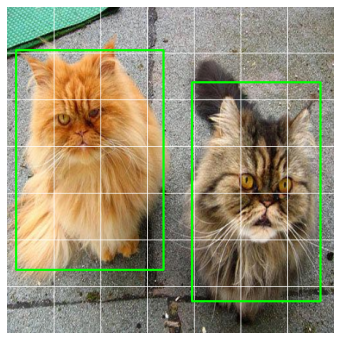

In [ ]:
a = train_dataset[0][0]
b = train_dataset[1][0]
a = a.unsqueeze(0).to(device)
b = b.unsqueeze(0).to(device)
with torch.no_grad():
    out1 = loaded_model(a)
    out2 = loaded_model(b)

print("Prediction difference:", (out1 - out2).abs().max().item())
a = train_dataset[0][0]
b = train_dataset[1][0]
show_yolo_label(b, out2[0], img_size=448, conf_threshold=0.5, S=7)

In [ ]:
S, B, C = 7, 2, 20

device = 'cuda'

loaded_model = YOLOv1(S=S, B=B, C=C).to(device)
loaded_model.load_state_dict(torch.load("yolov1_trained3.pth", map_location=device))
loaded_model.eval()

NameError: name 'S' is not defined

In [ ]:
def yolo_viz(img_tensor, pred_tensor, target_tensor=None, img_size=448, conf_threshold=0.3):
    """
    Visualize both predicted and ground truth boxes on the same image.
    Predicted boxes: green
    Ground truth boxes: red
    """

    
    # Convert tensor to numpy image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    S = 7
    step = img_size // S
    for i in range(S):
        for j in range(S):
            if target_tensor is not None:
                # === Ground truth ===
                tcell = target_tensor[i, j]
                if tcell[0] > 0:  # object present
                    tx, ty, tw, th = tcell[1:5]
                    label = my_classes[torch.argmax(tcell[B*5:])]
                    label = f"{label} : {tcell[0]}"
                    x_center = (j + tx) / S * img_size
                    y_center = (i + ty) / S * img_size
                    w_pixel = tw * img_size
                    h_pixel = th * img_size
                    x1 = int(x_center - w_pixel / 2)
                    y1 = int(y_center - h_pixel / 2)
                    x2 = int(x_center + w_pixel / 2)
                    y2 = int(y_center + h_pixel / 2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # RED = ground truth
                    cv2.putText(img, label, (x1, y1 - 5),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (36,255,12), 1)
            # === Prediction ===
            pcell = pred_tensor[i, j]
            for b in range(2):
                conf = torch.sigmoid(torch.tensor(pcell[0])).item()
                print(conf)
                if conf < conf_threshold:
                    continue
                label = my_classes[torch.argmax(pcell[B*5:])]
                label = f"{label} : {pcell[0]}"
                x, y, w, h = pcell[b*5+1:b*5+5]
                x_center = (j + x) / S * img_size
                y_center = (i + y) / S * img_size
                w_pixel = abs(w) * img_size
                h_pixel = abs(h) * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                x1 = max(0, min(x1, img.shape[1] - 1))
                x2 = max(0, min(x2, img.shape[1] - 1))
                y1 = max(0, min(y1, img.shape[0] - 1))
                y2 = max(0, min(y2, img.shape[0] - 1))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # GREEN = prediction
                cv2.putText(img, label, (x1, y1 - 5),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (36,255,12), 1)
    #plt.figure(figsize=(6,6))
    #plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    #plt.title("YOLO — Predicted (green) vs Ground Truth (red)")
    #plt.axis('off')
    #plt.show()
    return img

In [ ]:
#cap = cv2.VideoCapture(0)  # or 0 for camera
cap = cv2.VideoCapture("mixkit-play-between-two-teams-in-a-soccer-match-43481-hd-ready.mp4")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
desired_size = (480,480)
out = cv2.VideoWriter("output.mp4", fourcc, 20.0, desired_size)

while True:
    ret, img = cap.read()
    if not ret:
        break
    
    img = cv2.resize(img, (448, 448))
    img = img[..., ::-1]  # BGR to RGB
    img = img / 255.0
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).float()  # (C,H,W)
    #frame_tensor = frame_tensor.to(next(model.parameters()).device)

    img = img.to('cuda')
    results = loaded_model(img)
    #print(results)
    frame_out = yolo_viz(img[0], results[0], conf_threshold=0.61)

    # Write to video and display in real-time
    out.write(frame_out)
    cv2.imshow("YOLO Detection", frame_out)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()


C:\Users\Lucas\AppData\Local\Temp\ipykernel_14020\127747812.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


0.49532708525657654
0.49532708525657654
0.499276727437973
0.499276727437973
0.4983484745025635
0.4983484745025635
0.498687744140625
0.498687744140625
0.5074204802513123
0.5074204802513123
0.4957217872142792
0.4957217872142792
0.4964364171028137
0.4964364171028137
0.4986737370491028
0.4986737370491028
0.4987739622592926
0.4987739622592926
0.5113860964775085
0.5113860964775085
0.5120247006416321
0.5120247006416321
0.48091378808021545
0.48091378808021545
0.511195182800293
0.511195182800293
0.48338237404823303
0.48338237404823303
0.5769615769386292
0.5769615769386292
0.5455791354179382
0.5455791354179382
0.5002758502960205
0.5002758502960205
0.5148639678955078
0.5148639678955078
0.5315107107162476
0.5315107107162476
0.5254607200622559
0.5254607200622559
0.5239598155021667
0.5239598155021667
0.49435505270957947
0.49435505270957947
0.5375339388847351
0.5375339388847351
0.6929367780685425
0.6929367780685425
0.642571747303009
0.642571747303009
0.7299739718437195
0.7299739718437195
0.5755535364

In [ ]:
x_path = "horse_racing.jpg"

img = cv2.imread(x_path)
img = cv2.resize(img, (448, 448))
img = img[..., ::-1]  # BGR to RGB
img = img / 255.0
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # (C,H,W)

img = img.to('cuda')
pred = model(img.unsqueeze(0))
pred = pred.to('cuda')

compare_pred_vs_true(img,pred_tensor=pred[0], conf_threshold=0.61)
